In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [335]:
colors = sns.color_palette("dark:grey_r", n_colors=5, )

[(0.5019607843137255, 0.5019607843137255, 0.5019607843137255),
 (0.41305174966086156, 0.413053165666333, 0.41304818037951174),
 (0.3241427150079977, 0.3241455470189405, 0.324135576445298),
 (0.2352336803551338, 0.23523792837154806, 0.23522297251108426),
 (0.1477138493687209, 0.1477194912655211, 0.14769962801334263)]

In [402]:
colors2 = sns.color_palette("Blues", n_colors=5, )
colors2

[(0.8406920415224913, 0.9016378316032295, 0.9586620530565167),
 (0.6718954248366014, 0.8143790849673203, 0.9006535947712418),
 (0.41708573625528644, 0.6806305267204922, 0.8382314494425221),
 (0.21568627450980393, 0.5294117647058824, 0.7542483660130719),
 (0.06251441753171857, 0.35750865051903113, 0.6429065743944637)]

In [282]:
import matplotlib as mpl

mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

In [6]:
author_df = pd.read_pickle('2023-03-23_NB5_author_df.pkl')
papers_df = pd.read_pickle('2023-03-23_NB4_papers_df_part3.pkl')

Does the author with the most publications have the most number of 

In [520]:
papers_df[papers_df['PubTitle'] == 'nature']

,first_auth,second_auth,third_auth,Cites,ManuscriptTitle,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,PubTitle,PubType,SJR,H index,Country,Region,query_author
85,l quan,d ma,y zhao,2319,Perovskite lightemitting diodes with external ...,2018,2,2319,463.80,258,9,0,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
86,l zhang,sr jean,s ahmed,1897,Ultrasensitive solutioncast quantum dot photod...,2006,5,1897,111.59,271,7,0,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
87,x wang,z wang,tt zhuang,1258,Enhanced electrocatalytic CO2 reduction via fi...,2016,13,1258,179.71,140,9,0,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
88,fg dearquer,x gong,rp sabatini,1142,Materials interface engineering for solutionpr...,2012,15,1142,103.82,286,4,0,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
89,jy kim,v adinolfi,br sutherland,1088,Efficient and stable emission of warmwhite lig...,2018,20,1088,217.60,109,11,0,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,r quinterobermudez,ah proppe,a mahata,662,Highly efficient and stable InP/ZnSe/ZnS quant...,2019,1,662,165.50,66,10,444,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
144,z yang,m wei,o voznyy,1147,Perovskite solar cells with atomically coheren...,2021,1,1147,573.50,115,10,486,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
145,m askerka,z li,m lempen,286,Ligandengineered bandgap stability in mixedhal...,2021,1,286,143.00,41,7,491,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent
146,t peng,t zhuang,y yan,1146,Perovskite oxides for visiblelightabsorbing fe...,2013,1,1146,114.60,127,9,526,nature,journal,17.897,1276.0,United Kingdom,Western Europe,eh sargent


In [521]:
papers_df.iloc[85,:]

first_auth                                                    l quan
second_auth                                                     d ma
third_auth                                                    y zhao
Cites                                                           2319
ManuscriptTitle    Perovskite lightemitting diodes with external ...
Year                                                            2018
GSRank                                                             2
ECC                                                             2319
CitesPerYear                                                   463.8
CitesPerAuthor                                                   258
AuthorCount                                                        9
query_id                                                           0
PubTitle                                                      nature
PubType                                                      journal
SJR                               

In [70]:
author_df.columns[:20]

Index(['AuthorName', 'Mean_AuthorRank', 'Mean_Cites', 'Mean_Year',
       'Mean_GSRank', 'Mean_ECC', 'Mean_CitesPerYear', 'Mean_CitesPerAuthor',
       'Mean_AuthorCount', 'Mean_SJR', 'Mean_PubHindex', 'NumPapers_inDataset',
       'Author_Hindex', 'In_accounts of chemical research',
       'In_acs applied bio materials', 'In_acs applied electronic materials',
       'In_acs applied energy materials',
       'In_acs applied materials and interfaces',
       'In_acs applied nano materials', 'In_acs applied polymer materials'],
      dtype='object')

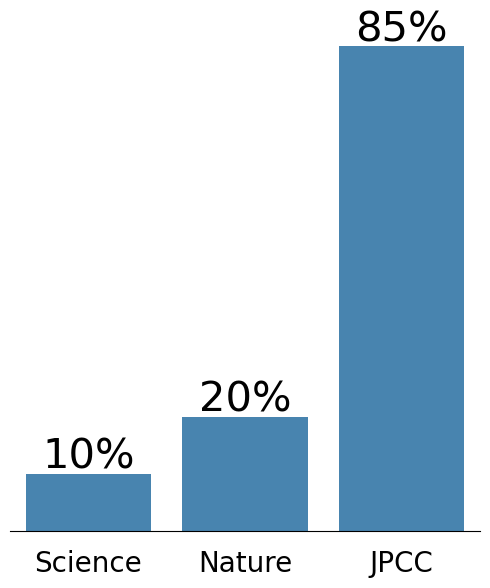

In [566]:
fig = plt.figure(figsize=(5,6))
mpl.rcParams['axes.spines.left'] = False
mpl.rcParams['axes.spines.bottom'] = True
per = pd.DataFrame({'Likliehood': [10, 20, 85], 'Journal': ['Science', 'Nature', 'JPCC']})
sns.barplot(data = per, x = 'Journal', y = 'Likliehood', color = colors2[3])
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize = 20)
plt.yticks([],[])
plt.tick_params(axis='x', length=10, color = 'white')

for index, row in per.iterrows():
    plt.text(row.name, row.values[0]+1, f'{row.values[0]}%', color='black', ha="center", fontsize = 30)

fig.tight_layout()
fig.savefig('predict.png', transparent = True, dpi = 100)

In [553]:
row.values

array([10, 'Science'], dtype=object)

Overview of DataSet:

In [38]:
import decimal

def round_to_ten(number):
    return round(number/10) * 10

def round_to_hund(number):
    return round(number/100) * 100

In [35]:
papers_df['Year'].apply(round_to_ten).value_counts(normalize = True)

2020    0.672043
2010    0.234247
2000    0.082739
1990    0.010133
1980    0.000779
1970    0.000060
Name: Year, dtype: float64

In [36]:
0.672043 + 0.234247

0.9062899999999999

In [269]:
np.arange(0.1, 1, 0.1)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

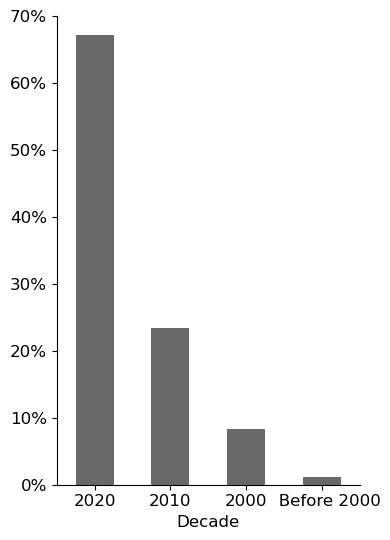

In [481]:
def group_dec(x):
    if x < 2000:
        return '   Before 2000'
    else:
        return str(x)

# Organize by decade
fig = plt.figure(figsize = (4, 5.5))
papers_df['Year'].apply(round_to_ten).apply(group_dec).value_counts(normalize = True).plot(kind = 'bar', color = colors[1], width = 0.5)
#plt.title('Distribution of Publications by Publication Decade')
plt.xticks(rotation = 0, fontsize = 12)

y_ticks = np.arange(0, 1, 0.1)
y_labels = ["{:.0%}".format(i) for i in y_ticks]
plt.yticks(ticks = y_ticks, labels = y_labels, fontsize = 12)
plt.ylim([0, 0.7])
plt.xlabel('Decade',fontsize = 12)
fig.tight_layout()
fig.savefig('year_dis.png', transparent = True, dpi = 100)

# Over 90% of publications were made after 2010

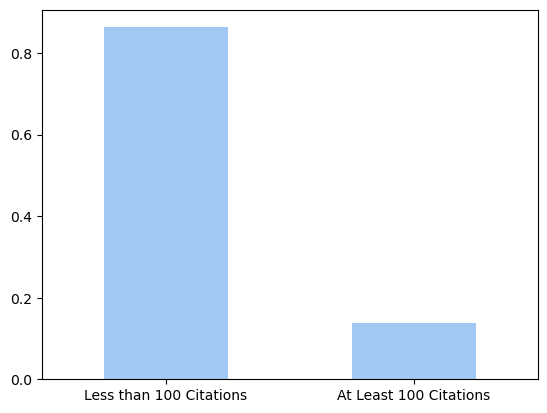

In [122]:
val = author_df['Mean_Cites'].values
cites = pd.Series(np.where(val < 100, 1, 0))
cites.value_counts(normalize = True).plot(kind = 'bar', color = colors[0])
plt.xticks([0,1], ['Less than 100 Citations', 'At Least 100 Citations'], rotation = 0);

In [365]:
pie

([<matplotlib.patches.Wedge at 0x265a514b760>,
 [Text(-0.9996861469527171, 0.4589418346488264, ''),
  Text(0.9996861469527173, -0.45894183464882604, '')],
 [Text(-0.5452833528833001, 0.2503319098084507, '86%'),
  Text(0.5452833528833003, -0.25033190980845055, '14%')])

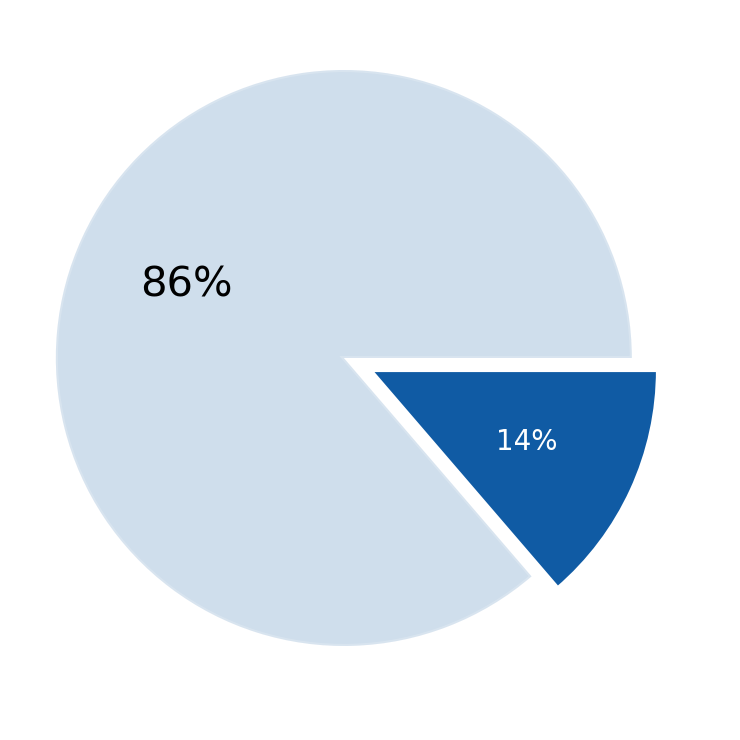

In [420]:
fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.subplots(1, 1)
vals = pd.Series(np.where(val < 100, 1, 0)).value_counts(normalize = True)

labels = ['Authors with\nLess than 100 Citations', 'Authors with\nMore than 100 Citations']
wedge, text, text2 = ax.pie(vals, colors = [colors2[4], colors2[4]], explode = [0.1, 0], autopct='%.0f%%',
        wedgeprops = {'linewidth': 3, 'edgecolor': 'white'},
                    textprops = {'fontsize': 20, 'color': 'white'});

text2[0].set_color('black')
text2[0].set_fontsize(30)
wedge[0].set_alpha(0.2)
fig.tight_layout()
fig.savefig('auth_100_cites.png', transparent = True, dpi = 100)

In [509]:
pub_val_cts = papers_df['PubTitle'].value_counts(normalize= True).sort_values(ascending = False)

In [507]:
cum_per = 100 * np.cumsum(pub_val_cts)/ np.sum(pub_val)

In [508]:
np.where(cum_per > 90)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177

In [510]:
i = 0 
for j in pub_val_cts.values:
    i = i + j
    if i > 0.9:
        print(j)
        break

0.0005396006954853409


In [511]:
pub_val_cts[pub_val_cts == 0.0005396006954853409]

physica scripta                                                       0.00054
europhysics letters                                                   0.00054
analytical chemistry                                                  0.00054
materials today energy                                                0.00054
scripta materialia                                                    0.00054
iscience                                                              0.00054
ieee transactions on magnetics                                        0.00054
european journal of organic chemistry                                 0.00054
industrial and engineering chemistry research                         0.00054
beilstein journal of nanotechnology                                   0.00054
iop conference series materials science and engineering               0.00054
applied sciences                                                      0.00054
physica c superconductivity and its applications                

In [458]:
group1 = pub_val_cts[:'nanotechnology']
group2 = pub_val_cts['acs applied energy materials':]

group1_cts = group1.count()
group1_sum = group1.sum()
group1_per = group1_cts/912

group2_cts = group2.count()
group2_per = group2_cts/912

In [460]:
papers_df['PubTitle'].value_counts(normalize = True)

journal of physical chemistry c         0.035794
advanced materials                      0.035254
applied physics letters                 0.032976
physical review b                       0.029738
acs applied materials and interfaces    0.024162
                                          ...   
ieee transactions on education          0.000060
hyperfine interactions                  0.000060
supramolecular chemistry                0.000060
smart materials in medicine             0.000060
science robotics                        0.000060
Name: PubTitle, Length: 912, dtype: float64

In [456]:
group2_per

0.9649122807017544

In [ ]:
'50% of the Entries are published to '

In [94]:
def group_round(val):
    
    assert isinstance(val, int) or isinstance(val, float)
    
    if val < 10:
        return 'Less Than 10 Entries'
    elif val > 10 and val < 100:
        return 'Between 10 and 100 Entries'
    elif val > 100:
        return 'More than 100 Entries'
        
val = author_df['NumPapers_inDataset'].apply(group_round).value_counts(normalize = True)

Less Than 10 Entries          0.945147
Between 10 and 100 Entries    0.051908
More than 100 Entries         0.002945
Name: NumPapers_inDataset, dtype: float64

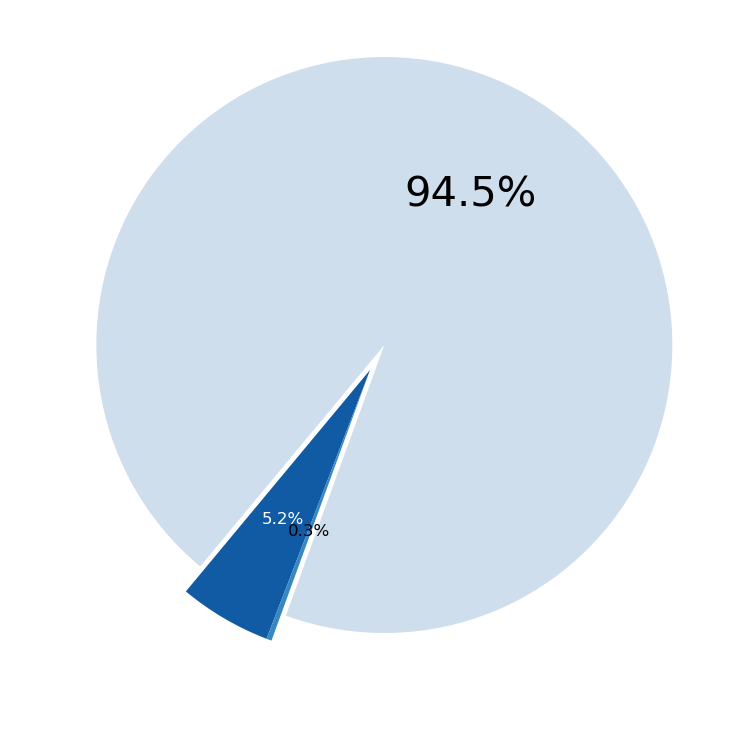

In [478]:
fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.subplots(1, 1)
vals = author_df['NumPapers_inDataset'].apply(group_round).value_counts(normalize = True)

wedge, text, text2 = ax.pie(vals, colors = [colors2[4], colors2[4], colors2[3]], explode = [0.1, 0, 0], autopct='%.1f%%',
                    textprops = {'fontsize': 12, 'color': 'black'}, startangle=250);

text2[1].set_color('white')
text2[0].set_fontsize(30)
wedge[0].set_alpha(0.2)
fig.tight_layout()
#fig.savefig('auth_100_cites.png', transparent = True, dpi = 100)

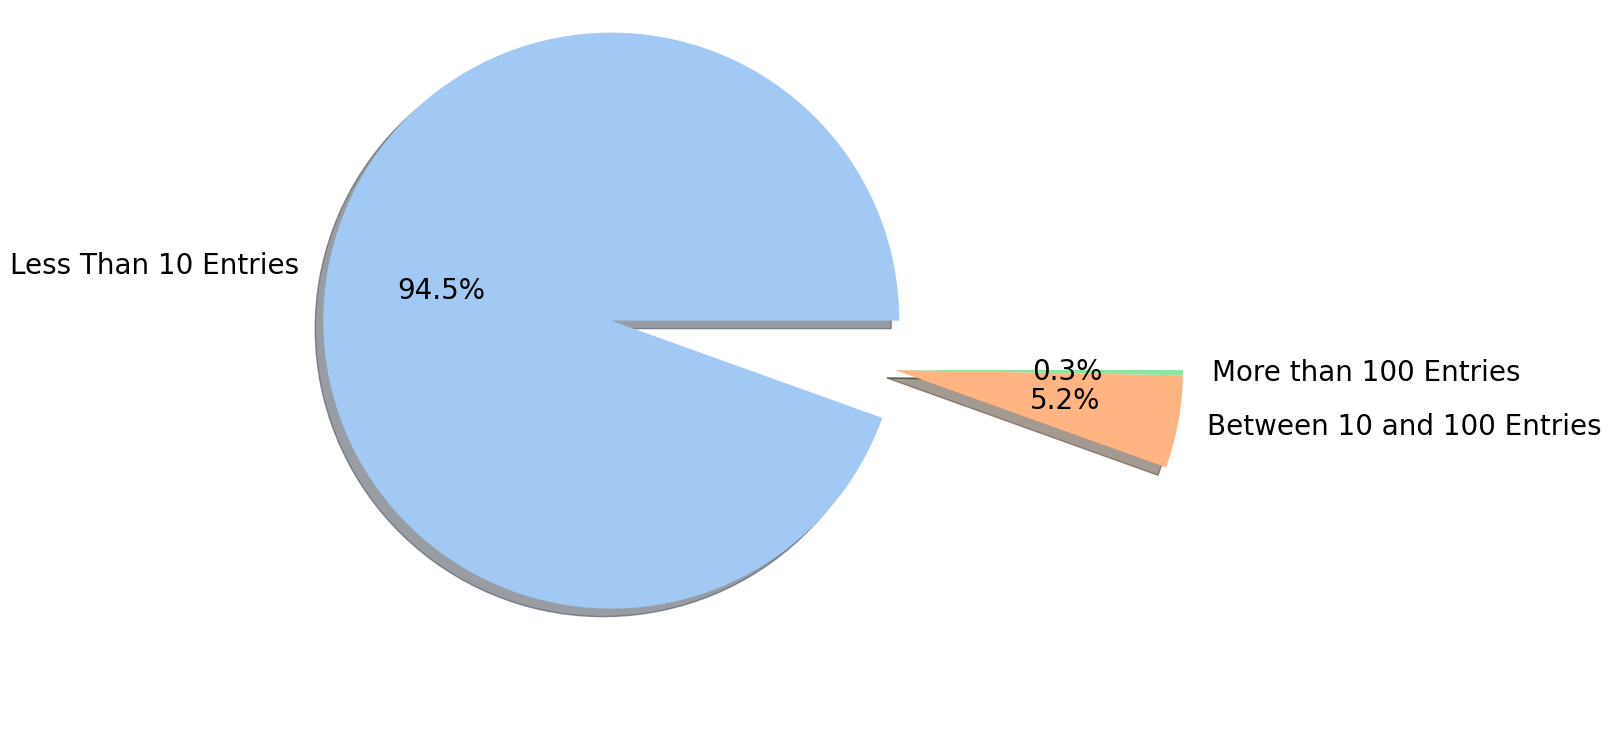

In [170]:
fig = plt.figure(figsize = (13.5, 7.5))
ax = fig.subplots(1, 1)
colors = sns.color_palette('pastel')[0:5]
vals = author_df['NumPapers_inDataset'].apply(group_round).value_counts(normalize = True)

explode = [1, 0,0]
ax.pie(vals, labels = vals.index, colors = colors, shadow = True, autopct='%.1f%%', explode=explode, 
       textprops = {'fontsize': 20});

fig.tight_layout()

In [220]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [197]:
author_df['Mean_PubHindex'].values

array([ 89. , 377.2,  99. , ..., 563. , 563. , 361. ], dtype=float16)

In [ ]:
author_id = pd.Series()

In [238]:
from scipy.stats import chi2_contingency

# Create a contingency table
ct = pd.crosstab(author_df['Mean_PubHindex'].apply(round_to_ten), author_df['AuthorName'].index)

# Perform chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Print results
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Expected frequencies:\n", expected)

Chi-square statistic: 1492581.9999999993
Degrees of freedom: 1492491
p-value: 0.47884377597295663
Expected frequencies:
 [[0.00054871 0.00054871 0.00054871 ... 0.00054871 0.00054871 0.00054871]
 [0.00573101 0.00573101 0.00573101 ... 0.00573101 0.00573101 0.00573101]
 [0.01377881 0.01377881 0.01377881 ... 0.01377881 0.01377881 0.01377881]
 ...
 [0.0013413  0.0013413  0.0013413  ... 0.0013413  0.0013413  0.0013413 ]
 [0.0001829  0.0001829  0.0001829  ... 0.0001829  0.0001829  0.0001829 ]
 [0.00109743 0.00109743 0.00109743 ... 0.00109743 0.00109743 0.00109743]]


<AxesSubplot:xlabel='col_0', ylabel='Mean_PubHindex'>

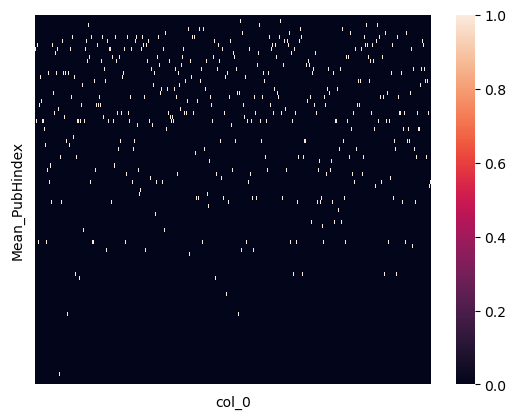

In [242]:
sns.heatmap(ct, xticklabels = False, yticklabels = False)

In [240]:
ct.shape

(92, 16402)

In [221]:
scaled = MinMaxScaler(feature_range=(0, 1)).fit_transform(np.asarray(ct))

In [224]:
scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

significant relationship between these two metrics

In [252]:
papers_df.columns

Index(['first_auth', 'second_auth', 'third_auth', 'Cites', 'ManuscriptTitle',
       'Year', 'GSRank', 'ECC', 'CitesPerYear', 'CitesPerAuthor',
       'AuthorCount', 'query_id', 'PubTitle', 'PubType', 'SJR', 'H index',
       'Country', 'Region', 'query_author'],
      dtype='object')

In [266]:
# Create a contingency table
ct = pd.crosstab(papers_df['H index'].apply(round_to_ten), papers_df['query_id'])

# Perform chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Print results
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Expected frequencies:\n", expected)

Chi-square statistic: 57108.65163780529
Degrees of freedom: 26553
p-value: 0.0
Expected frequencies:
 [[4.64296421e-01 2.46657473e-01 2.13681875e-01 ... 1.31902392e-03
  6.59511961e-04 1.31902392e-03]
 [4.51633791e+00 2.39930451e+00 2.07854188e+00 ... 1.28305054e-02
  6.41525271e-03 1.28305054e-02]
 [1.06788177e+01 5.67312189e+00 4.91468313e+00 ... 3.03375502e-02
  1.51687751e-02 3.03375502e-02]
 ...
 [8.01966545e-01 4.26044727e-01 3.69086876e-01 ... 2.27831405e-03
  1.13915702e-03 2.27831405e-03]
 [3.58774507e+00 1.90598957e+00 1.65117813e+00 ... 1.01924576e-02
  5.09622879e-03 1.01924576e-02]
 [2.65915223e+00 1.41267462e+00 1.22381438e+00 ... 7.55440974e-03
  3.77720487e-03 7.55440974e-03]]


<AxesSubplot:xlabel='query_id', ylabel='H index'>

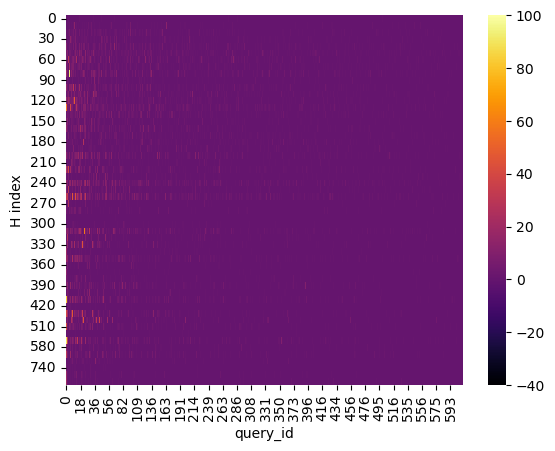

In [267]:
sns.heatmap(ct, cmap = 'inferno', vmin = -40, vmax = 100)

In [174]:
plt.imshow()

260     945
240     761
80      654
130     627
200     603
       ... 
1050      1
810       1
720       1
960       1
790       1
Name: Mean_PubHindex, Length: 92, dtype: int64

In [177]:
author_df['Author_Hindex'].apply(round_to_ten).value_counts()

0      15007
10      1104
20       191
30        44
40        31
50        13
100        3
60         2
90         2
80         2
120        1
240        1
70         1
Name: Author_Hindex, dtype: int64

Text(0.5, 1.0, 'Distribution of Mean Authorship Position')

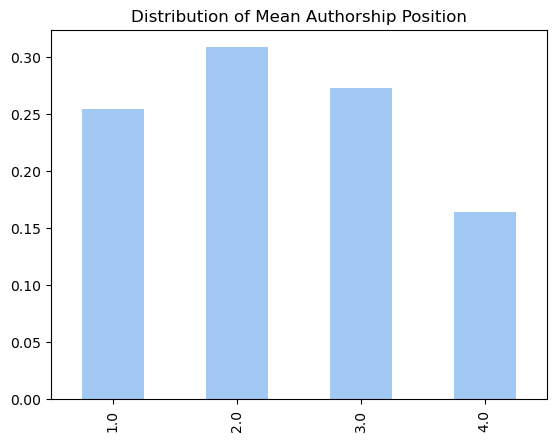

In [120]:
author_df['Mean_AuthorRank'].round().value_counts(normalize = True).sort_index().plot(kind = 'bar', color = colors[0])
plt.title('Distribution of Mean Authorship Position')

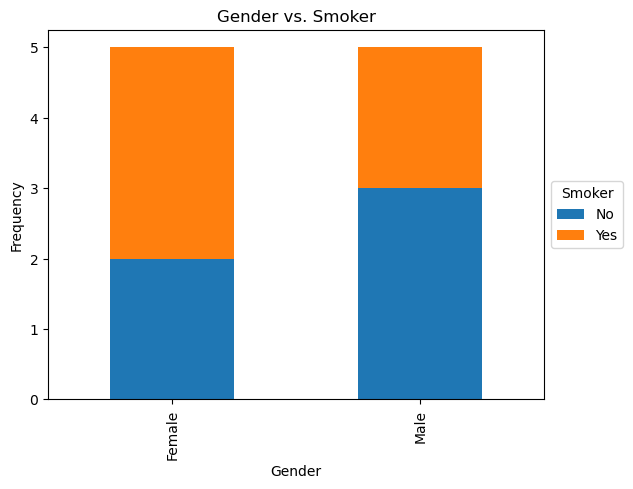

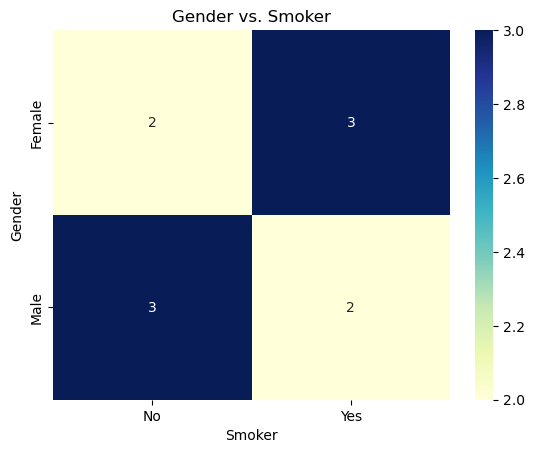

In [203]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example data
df = pd.DataFrame({'Gender': ['Male', 'Male', 'Female', 'Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Female'],
                   'Smoker': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes']})

# Create a contingency table
ct = pd.crosstab(df['Gender'], df['Smoker'])

# Create a stacked bar chart
ct.plot(kind='bar', stacked=True)
plt.title('Gender vs. Smoker')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.legend(title='Smoker', loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# Create a heatmap
sns.heatmap(ct, annot=True, cmap='YlGnBu')
plt.title('Gender vs. Smoker')
plt.xlabel('Smoker')
plt.ylabel('Gender')
plt.show()


people with the most publications 